# MultiOutputKriging on a curve-valued simulator (Julia)

A simulator often returns a **curve** per run rather than a single number. Here each run returns the damped
oscillation

$$y(x, t) = e^{-a(x)\,t} \cos\!\left(\frac{2\pi f(x)\, t}{5}\right),\qquad f = 0.5 + x_1,\quad a = 0.1 + 0.5\,x_2,$$

sampled at $q = 50$ time steps, for two inputs $x \in [0, 1]^2$. `MultiOutputKriging` fits the $q$ outputs at once:
`Y` is an $n \times q$ matrix (one row per run, one column per time step), with the same rows as `X`.

Four output models are compared (see [docs/math/MultiOutput.md](../../docs/math/MultiOutput.md)):

- **`"pca"`**: Karhunen-Loève reduction of the curves, one `Kriging` per principal score (Higdon et al. 2008);
- **`"shared"`**: one correlation length vector θ for all outputs, outputs independent given θ (parallel partial
  GP, Gu & Berger 2016);
- **`"separable"`**: a free $q \times q$ output covariance Σ (intrinsic coregionalization model), here on 3 outputs;
- **`"separable(matern5_2)"`**: Σ = σ² R_t(φ), a Matérn 5/2 kernel over the time steps, on the 50 outputs.

Steps:
1. Setup
2. Simulator and design ($n = 60$ runs)
3. `"pca"`: fit, predicted curves, accuracy and coverage
4. `"shared"`: one θ for the 50 outputs
5. Baseline: one independent `Kriging` per output
6. `"separable"`: joint covariance between outputs
7. `"separable(matern5_2)"`: a kernel over the time steps
8. `update` and `update_simulate`: new runs without refitting
9. `save` and `load`
10. Summary

## 0. Setup

Build the C++ core with the Julia binding (`-DENABLE_JULIA_BINDING=ON`) and develop the package (skip if already
done), see [bindings/Julia/README.md](README.md). Requires `cmake`, a C++ compiler, Julia ≥ 1.10.

```shell
julia -e 'using Pkg; Pkg.develop(path="bindings/Julia/jlibkriging")'
```

## 1. Load jlibkriging

In [1]:
using jlibkriging
using Plots
using Random
using Printf

# small helpers (no Statistics dependency)
mean(a) = sum(a) / length(a)
sd(a) = sqrt(sum((a .- mean(a)) .^ 2) / (length(a) - 1))
println("jlibkriging loaded")

jlibkriging loaded


## 2. Simulator and design

$n = 60$ runs on a random design, and 200 test runs to measure the accuracy.

X: (

60, 2)  Y: (60, 50)


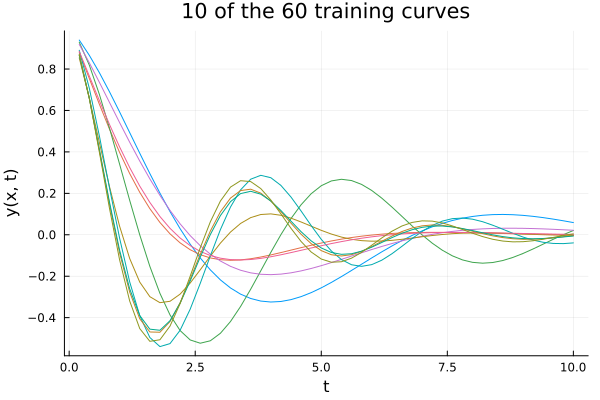

In [2]:
t = collect(range(0.2, 10, length=50))            # q = 50 time steps

function simulator(X)
    f = 0.5 .+ X[:, 1]
    a = 0.1 .+ 0.5 .* X[:, 2]
    return exp.(-a .* t') .* cos.(2π .* f .* t' ./ 5)   # n x q
end

Random.seed!(1)
X = rand(60, 2)
Y = simulator(X)
Xt = rand(200, 2)
Yt = simulator(Xt)
println("X: ", size(X), "  Y: ", size(Y))

plot(t, Y[1:10, :]', legend=false, xlabel="t", ylabel="y(x, t)", title="10 of the 60 training curves")

## 3. `"pca"` output model

`"pca(0.999)"` keeps the principal components that explain 99.9 % of the variance of the centered curves, and fits
one `Kriging` per component score. The truncation residual is kept as white noise, so the predicted standard
deviation does not ignore the discarded components.

In [3]:
t_pca = @elapsed pca = MultiOutputKriging(Y, X, "matern5_2"; output_model="pca(0.999)")
println(jlibkriging.summary(pca))
println("components: ", nb_components(pca), "  cumulative explained variance: ", round.(pca_explained(pca), digits=4))

* MultiOutputKriging, output model: pca(0.999)
  * covariance kernel: matern5_2
  * data: 60 x 2 -> 60 x 50
  * trend: constant
  * PCA components: 7, explained variance: 0.99966
    - component 0: cum. explained 0.555802, sigma2 1.8085, theta    0.6343   1.2744
    - component 1: cum. explained 0.826811, sigma2 2.02024, theta    0.4857   0.9985
    - component 2: cum. explained 0.933202, sigma2 0.987724, theta    0.3027   0.6806
    - component 3: cum. explained 0.975151, sigma2 0.545977, theta    0.2785   0.6629
    - component 4: cum. explained 0.988669, sigma2 0.138827, theta    0.2616   0.6131
    - component 5: cum. explained 0.997659, sigma2 0.131491, theta    0.2420   0.5723
    - component 6: cum. explained 0.99966, sigma2 0.0153722, theta    0.2008   0.4943



components: 7

  cumulative explained variance: [0.5558, 0.8268, 0.9332, 0.9752, 0.9887, 0.9977, 0.9997]


In [4]:
scores(m, s) = (sqrt(mean((m .- Yt) .^ 2)) / sd(vec(Yt)), mean(abs.(m .- Yt) .<= 1.96 .* s))

p = predict(pca, Xt)
println("mean, stdev: ", size(p.mean), " ", size(p.stdev))
r_pca = scores(p.mean, p.stdev)
@printf("pca: RMSE / sd(Y) = %.4f, coverage of the 95%% intervals = %.3f\n", r_pca...)

mean, stdev: (200, 50) (200, 50)
pca: RMSE / sd(Y) = 0.0488, coverage of the 95% intervals = 0.941


Predicted curves at three test inputs: predicted mean (solid), 95 % band (mean ± 1.96 stdev, shaded) and true
curve (dashed).

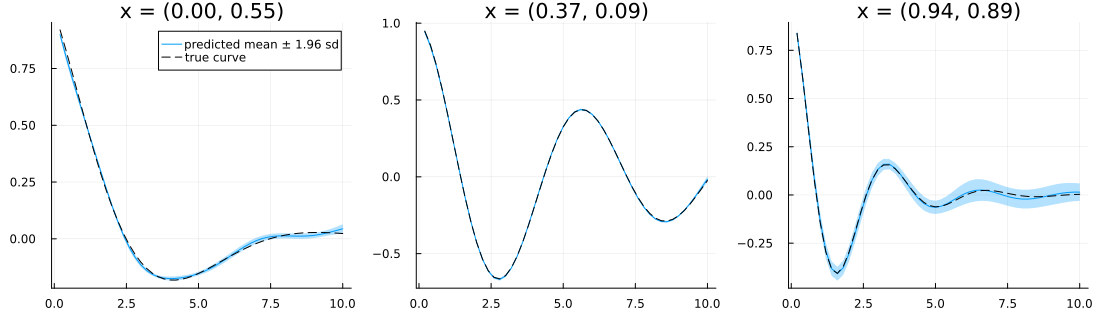

In [5]:
plots = map(1:3) do i
    plot(t, p.mean[i, :], ribbon=1.96 .* p.stdev[i, :], fillalpha=0.3, label="predicted mean ± 1.96 sd",
         title=@sprintf("x = (%.2f, %.2f)", Xt[i, 1], Xt[i, 2]), xlabel="t", legend=(i == 1))
    plot!(t, Yt[i, :], linestyle=:dash, color=:black, label="true curve")
end
plot(plots..., layout=(1, 3), size=(1100, 320))

## 4. `"shared"` output model

One θ for all 50 outputs, maximizing the summed concentrated log-likelihood: each likelihood evaluation costs
**one** Cholesky factorization for the 50 outputs. Each output keeps its own trend β_j and variance σ_j².

In [6]:
t_shared = @elapsed shared = MultiOutputKriging(Y, X, "matern5_2"; output_model="shared")
println("theta: ", theta(shared))
ps = predict(shared, Xt)
r_shared = scores(ps.mean, ps.stdev)
@printf("shared: RMSE / sd(Y) = %.4f, coverage = %.3f\n", r_shared...)

theta: [0.7850757606493917, 1.46566131750468]
shared: RMSE / sd(Y) = 0.0543, coverage = 0.937


## 5. Baseline: one independent `Kriging` per output

50 separate fits, each with its own θ. This remains a valid baseline: each time step gets the θ that suits it,
which can be slightly more accurate or not, depending on the design. The cost is 50 optimizations instead of one (`"shared"`) or a
handful (`"pca"`), no information shared between time steps, and no joint covariance between outputs.

In [7]:
t_indep = @elapsed models = [Kriging(Y[:, j], X, "matern5_2") for j in 1:size(Y, 2)]
pi_ = [predict(k, Xt) for k in models]
r_indep = scores(reduce(hcat, [q.mean for q in pi_]), reduce(hcat, [q.stdev for q in pi_]))
@printf("independent: RMSE / sd(Y) = %.4f, coverage = %.3f\n", r_indep...)

independent: RMSE / sd(Y) = 0.0401, coverage = 0.958


## 6. `"separable"` output model: joint covariance

`"separable"` estimates a free output covariance Σ (here between 3 close time steps, $t \approx 4.2, 4.6, 5.0$,
which are strongly correlated). Its predictive
covariance couples the outputs, $\mathrm{Cov}(\mathrm{vec}\,Y_n) = \Sigma \otimes C_x$, so it gives a consistent
uncertainty for any combination of outputs, e.g. the difference $Y(t_1) - Y(t_2)$. `"shared"` treats the outputs
as independent and gets that variance wrong when they are correlated.

`"separable"` needs $n - p \ge q$ and refuses nearly linearly dependent outputs (such as the 50 finely sampled time
steps): use `"pca"` or `"separable(<kernel>)"` for whole curves.

In [8]:
cols = [21, 23, 25]                                # t ~ 4.2, 4.6, 5.0
println("t: ", round.(t[cols], digits=2))
sep = MultiOutputKriging(Y[:, cols], X, "matern5_2"; output_model="separable")
S = output_cov(sep)
d = sqrt.([S[i, i] for i in 1:3])
display(round.(S ./ (d * d'), digits=3))

t: [4.2, 4.6, 5.0]


3×3 Matrix{Float64}:
 1.0    0.859  0.468
 0.859  1.0    0.848
 0.468  0.848  1.0

Check on the test runs: compare the standard deviation of the standardized errors (error / predicted stdev) of
$Y(t_1)$ alone and of the difference $Y(t_1) - Y(t_2)$. Both models are conservative on $Y(t_1)$ alone (smooth
kernel), with a standard deviation below 1. `"separable"` stays of the same order for the difference;
`"shared"` ignores the correlation between the outputs, so its predicted variance of the difference is many times
too large and the standardized errors are much smaller than 1.

In [9]:
function calibration(model)
    # sd of the standardized errors of Y(t1) alone and of Y(t1) - Y(t2), from the joint covariance
    q = predict(model, Xt; return_cov=true)
    M = size(Xt, 1)
    v = [q.cov[i, i] + q.cov[M + i, M + i] - 2 * q.cov[i, M + i] for i in 1:M]
    err1 = q.mean[:, 1] .- Yt[:, cols[1]]
    err = (q.mean[:, 1] .- q.mean[:, 2]) .- (Yt[:, cols[1]] .- Yt[:, cols[2]])
    return sd(err1 ./ q.stdev[:, 1]), sd(err ./ sqrt.(v))
end

sh3 = MultiOutputKriging(Y[:, cols], X, "matern5_2"; output_model="shared")
println("sd of the standardized errors:     Y(t1)   Y(t1) - Y(t2)")
for (name, model) in [("separable", sep), ("shared", sh3)]
    c = calibration(model)
    @printf("  %-10s                     %5.2f   %5.2f\n", name, c...)
end

f = predict_cov_factors(sep, Xt[1:5, :])
println("predict_cov_factors: ", size(f.Cx), " ", size(f.Sigma))

sd of the standardized errors:     Y(t1)   Y(t1) - Y(t2)
  separable                       0.85    0.89
  shared                          0.81    0.34


predict_cov_factors: (5, 5) (3, 3)


## 7. `"separable(matern5_2)"`: a kernel over the time steps

With the time steps as output coordinates, Σ can be a kernel over them: $\Sigma = \sigma^2 R_t(\phi)$, here a
Matérn 5/2 correlation in $t$ with one range φ, estimated with θ by maximum likelihood. Two parameters replace the
$q(q+1)/2 = 1275$ entries of a free Σ, so the 50 finely sampled outputs are not a problem (the free Σ of
`"separable"` is singular there). The predictive mean is that of `"shared"` at the same θ; the joint covariance
couples all the time steps.

`normalize=true` gives each time step its own scale, which matters here since the curves decay along $t$.

In [10]:
t_sk = @elapsed sk = MultiOutputKriging(Y, X, "matern5_2"; output_model="separable(matern5_2)", normalize=true,
                                        output_coordinates=t)
println("theta: ", round.(theta(sk), digits=3), "  phi (range in t): ", round.(output_theta(sk), digits=3))
pk = predict(sk, Xt)
r_sk = scores(pk.mean, pk.stdev)
@printf("separable(matern5_2): RMSE / sd(Y) = %.4f, coverage = %.3f\n", r_sk...)
S = output_cov(sk)
println("output correlation of t = 4.2 with t = 4.6, 5.0: ", round.(S[21, [23, 25]] ./ S[21, 21], digits=3))

theta: 

[0.291, 0.685]  phi (range in t): [1.078]
separable(matern5_2): RMSE / sd(Y) = 0.0417, coverage = 0.966
output correlation of t = 4.2 with t = 4.6, 5.0: [0.898, 0.681]


Over all outputs, the standardized errors (error / predicted stdev) have a standard deviation somewhat below 1
(about 0.6 to 1 depending on the design): the model is a little conservative. Without `normalize=true` it is far
more so (about 0.07 on this design, coverage 1). The reason is that $R_t$ is **stationary**: one variance and one
correlation structure for the whole time axis, while these curves start from 1 for every input and decay along $t$.
Scaling each time step absorbs the decay; what remains is a correlation in $t$ that depends on $x$ (the frequency).
`"pca"` adapts to such curves without any assumption on $t$; `"separable(<kernel>)"` suits outputs whose
correlation depends mainly on the distance in $t$ (spatial fields, stationary time series), and gives a joint
covariance over all of them.

In [11]:
@printf("sd of the standardized errors (all outputs): separable(matern5_2) %.2f, pca %.2f\n",
        sd(vec((pk.mean .- Yt) ./ pk.stdev)), sd(vec((p.mean .- Yt) ./ p.stdev)))

sd of the standardized errors (all outputs): separable(matern5_2) 0.76, pca 1.07


## 8. `update` and `update_simulate`

`simulate(..., will_update=true)` draws joint trajectories of all outputs and keeps what `update_simulate` needs.
When 5 new runs arrive, `update_simulate` conditions the **same** trajectories on them, without refitting. Its
empirical mean should match the prediction of the model updated with `update(..., refit=false)`.

simulate: (

4, 50, 2000) (m x q x nsim)
max |empirical mean - updated mean| / max stdev: 0.0235


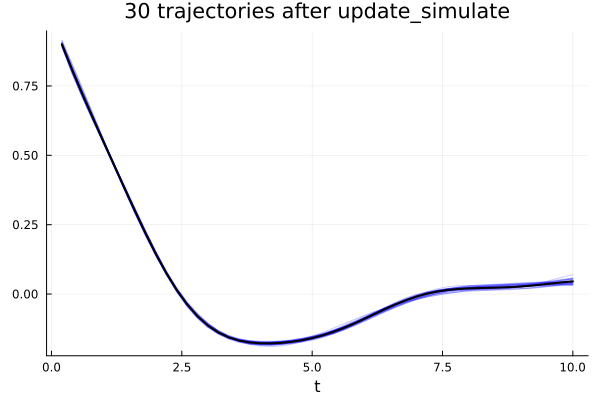

In [12]:
xs = Xt[1:4, :]                                    # where the trajectories are drawn
Xu, Yu = Xt[101:105, :], Yt[101:105, :]            # 5 new runs
sims = simulate(pca, 2000, 7, xs; will_update=true)
println("simulate: ", size(sims), " (m x q x nsim)")
sims_u = update_simulate(pca, Yu, Xu)

update!(pca, Yu, Xu; refit=false)
pu = predict(pca, xs)
emp = dropdims(sum(sims_u; dims=3); dims=3) ./ size(sims_u, 3)
@printf("max |empirical mean - updated mean| / max stdev: %.4f\n", maximum(abs.(emp .- pu.mean)) / maximum(pu.stdev))

plot(t, sims_u[1, :, 1:30], color=:blue, alpha=0.2, legend=false, xlabel="t",
     title="30 trajectories after update_simulate")
plot!(t, pu.mean[1, :], color=:black, linewidth=2)

## 9. `save` and `load`

`save` writes the configuration, the data and the fitted state to a JSON file; `load` restores it exactly
(the generic `load` of each binding recognizes the file). The state of the last `simulate` is not saved: simulate
again before `update_simulate`.

In [13]:
f = tempname() * ".json"
save(pca, f)                                       # the updated pca model of section 8
loaded = jlibkriging.load(f)                       # or load_multi_output_kriging(f)
println(typeof(loaded), " ", output_model(loaded), " ", nb_components(loaded), " components")
println("max |difference| of the predicted means: ", maximum(abs.(predict(pca, Xt).mean .- predict(loaded, Xt).mean)))

MultiOutputKriging 

pca(0.999) 7 components
max |difference| of the predicted means: 0.0


## 10. Summary

| Output model | Use it for | Hyperparameters |
|---|---|---|
| `"pca"` | many correlated outputs: curves, fields, q ≫ n possible | one Kriging per principal score |
| `"shared"` | outputs of similar regularity, marginal predictions | one θ, (β_j, σ_j²) per output |
| `"separable"` | a few correlated outputs, joint covariance or joint simulations | one θ, β_j per output, free Σ |
| `"separable(<kernel>)"` | outputs with coordinates and a stationary correlation along them, q ≫ n possible | one θ, β_j per output, σ², φ |

All four share the kernels, trends, `normalize` and optimizers of `Kriging`. Current limitations: isotopic design
only (no missing value in `Y`), no noise/nugget.

In [14]:
@printf("%-12s %10s %9s %13s\n", "model", "RMSE/sd(Y)", "coverage", "fit time (s)")
for (name, r, tt) in [("pca", r_pca, t_pca), ("shared", r_shared, t_shared), ("independent", r_indep, t_indep),
                      ("sep(matern)", r_sk, t_sk)]
    @printf("%-12s %10.4f %9.3f %13.2f\n", name, r..., tt)
end

model        RMSE/sd(Y)  coverage  fit time (s)
pca              0.0488     0.941          0.14


shared           0.0543     0.937          0.02
independent      0.0401     0.958          0.43
sep(matern)      0.0417     0.966          0.07
